In [24]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [25]:
x,y = make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

In [26]:
x.shape

(1000, 2)

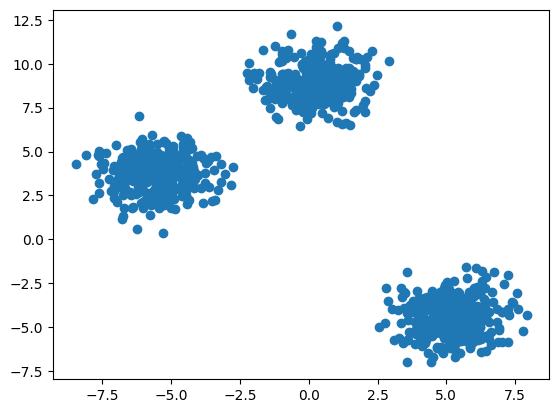

In [27]:
plt.scatter(x[:,0],x[:,1])

In [28]:
from sklearn.model_selection import train_test_split

x_train, x_test,y_train,y_test = train_test_split(x,y, test_size=0.33,random_state=42)

In [29]:
from sklearn.cluster import KMeans

In [30]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarni

In [31]:
wcss

[34827.57682552022,
 7935.437286145416,
 1319.2730531585607,
 1140.467788465513,
 992.0708509383512,
 853.321943591877,
 756.6587223292171,
 663.7914115355859,
 578.8190132531436,
 533.3106373018633]

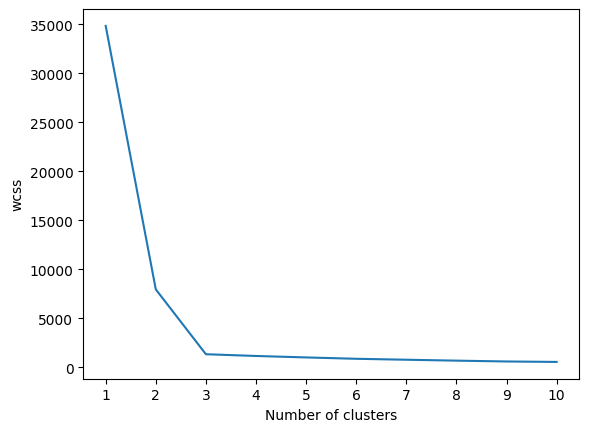

In [32]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("wcss")
plt.show()

In [33]:
kmeans = KMeans(n_clusters=3,init='k-means++')

In [34]:
y_labels = kmeans.fit_predict(x_train)

/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


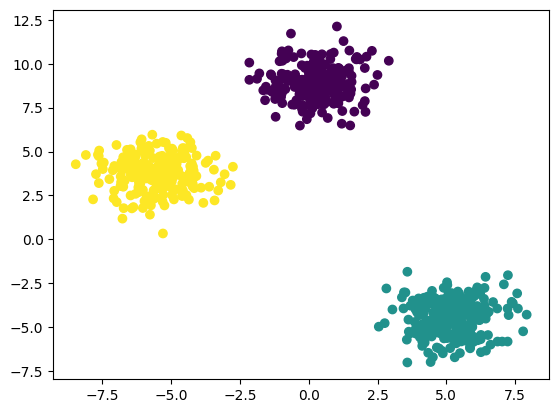

In [35]:
plt.scatter(x_train[:,0], x_train[:,1], c=y_labels)

In [36]:
from kneed import KneeLocator

In [37]:
kl = KneeLocator(range(1,11),wcss, curve='convex',direction='decreasing')
kl.elbow

3

In [38]:
from sklearn.metrics import silhouette_score

In [39]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init = 'k-means++')
    kmeans.fit(x_train)
    score = silhouette_score(x_train,kmeans.labels_)
    silhouette_coefficients.append(score)

/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarni

In [40]:
silhouette_coefficients

[0.7281443868598331,
 0.8071181203797672,
 0.6357733426488265,
 0.4814001336222496,
 0.33828198602773246,
 0.3487494498071299,
 0.33233417876244137,
 0.3452009234358577,
 0.3401479622526143]

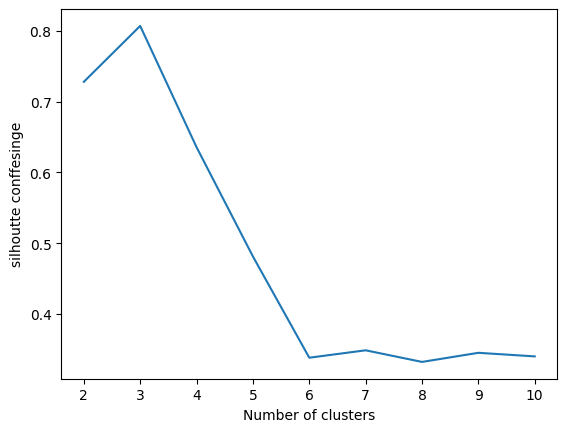

In [41]:
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("silhoutte conffesinge")
plt.show()

## Hierarichal clustaring Implementation

In [ ]:
from sklearn import datasets

In [ ]:
iris = datasets.load_iris()

In [ ]:
df = pd.DataFrame(iris['data'],columns=iris['feature_names'])

In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

In [ ]:
x_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=2)

In [ ]:
pca_scaled = pca.fit_transform(x_scaled)

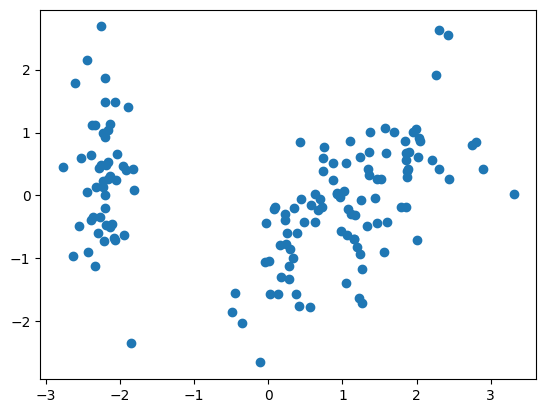

In [ ]:
plt.scatter(pca_scaled[:,0], pca_scaled[:,1])

In [ ]:
import scipy.cluster.hierarchy as sc

Text(0, 0.5, 'Eucledian distance')

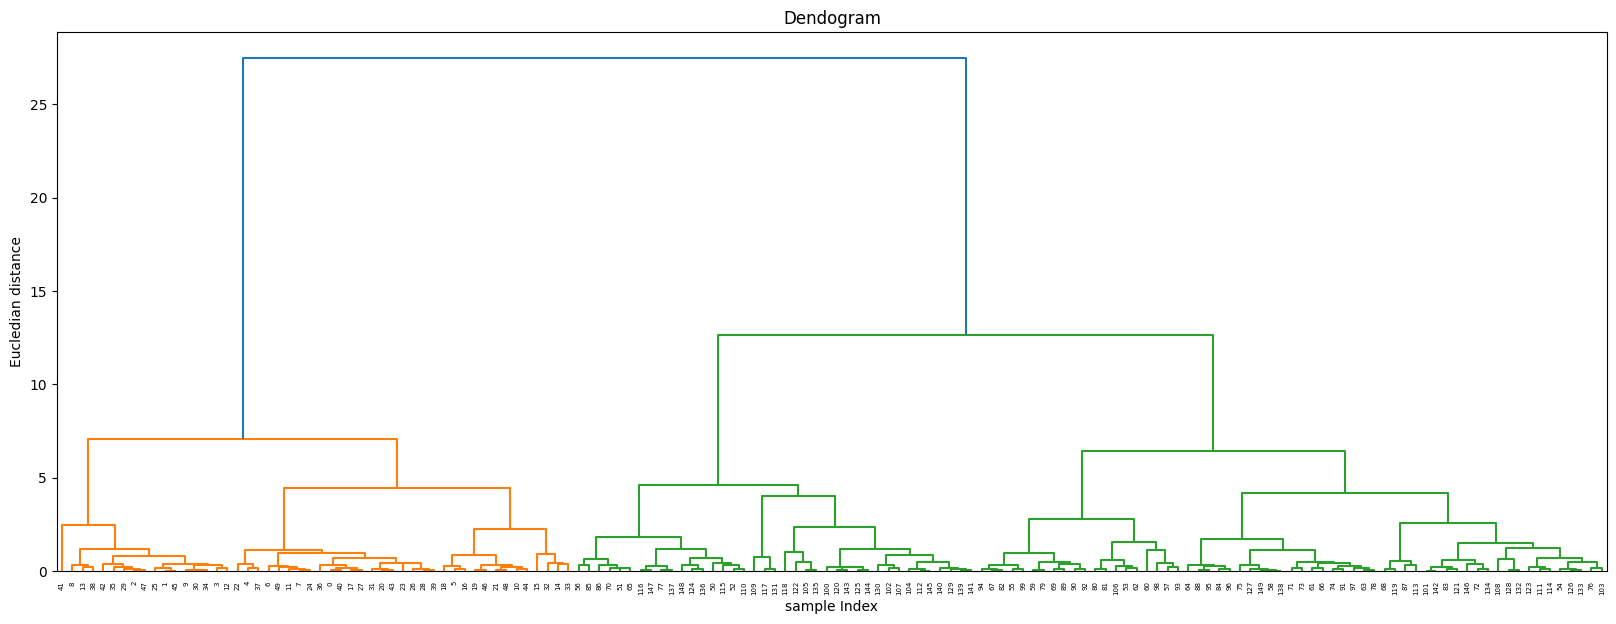

In [ ]:
plt.figure(figsize=(20,7))
plt.title("Dendograms")

sc.dendrogram(sc.linkage(pca_scaled,method='ward'))
plt.title('Dendogram')
plt.xlabel('sample Index')
plt.ylabel('Eucledian distance')

In [ ]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=2,affinity='euclidean',linkage='ward')
cluster.fit(pca_scaled)



/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_agglomerative.py:1006: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


AgglomerativeClustering(affinity='euclidean')

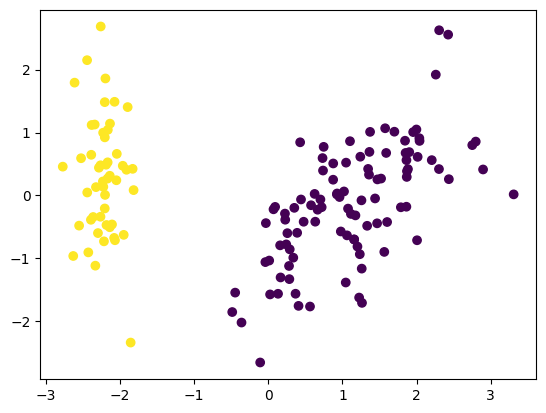

In [ ]:
cluster.labels_
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c = cluster.labels_)

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init = 'k-means++')
    kmeans.fit(x_train)
    score = silhouette_score(x_train,kmeans.labels_)
    silhouette_coefficients.append(score)

/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarni

In [ ]:
silhouette_coefficients

[0.7281443868598331,
 0.8071181203797672,
 0.6357733426488265,
 0.4907093255057165,
 0.33367872107343594,
 0.34575016442546685,
 0.3492617247267003,
 0.34651811680098216,
 0.34256414842349187]

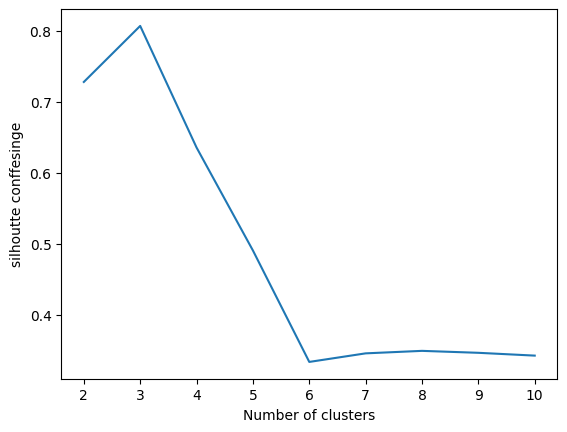

In [ ]:
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("silhoutte conffesinge")
plt.show()

## DBSCAN Clustaring 

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons 

In [ ]:
x,y = make_moons(n_samples=250,noise=0.05)

In [ ]:
x

array([[ 1.29229239e+00, -5.11236272e-01],
       [-7.30522135e-01,  7.53068367e-01],
       [ 7.62929150e-01,  8.08660217e-01],
       [ 1.79660312e+00, -6.13436984e-02],
       [-9.12150782e-01,  4.98829009e-01],
       [-4.52612752e-02,  3.77066468e-01],
       [ 1.69456502e+00, -2.28785885e-01],
       [-1.42650210e-02,  2.18985530e-01],
       [-9.22304666e-01,  4.65665754e-01],
       [ 1.57337880e-01,  7.84240883e-02],
       [ 1.39004311e+00, -3.42345031e-01],
       [ 1.77615411e+00,  1.91311275e-02],
       [ 3.45635588e-01, -2.15295407e-01],
       [ 4.34012948e-01,  8.34401397e-01],
       [ 2.13812234e-01,  9.99555387e-01],
       [ 1.44195106e+00, -5.02608305e-01],
       [-3.00150888e-01,  1.02106390e+00],
       [ 8.73284297e-01,  3.72098597e-01],
       [ 5.20516641e-01, -4.41818994e-01],
       [ 1.08402946e+00, -5.60198694e-01],
       [ 8.59598898e-01,  5.40961812e-01],
       [ 4.16202807e-01, -2.30718828e-01],
       [ 3.36392229e-01, -3.10455089e-01],
       [ 4.

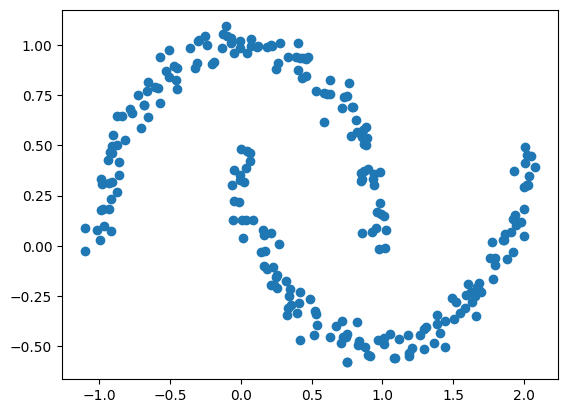

In [ ]:
plt.scatter(x[:,0],x[:,1])

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
dbcan = DBSCAN(eps = 0.5)

In [ ]:
dbcan.fit(x_scaled)

DBSCAN()

In [ ]:
dbcan.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1, -1, -1,  1, -1, -1,  1, -1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1, -1,  1,
        1,  1,  1, -1, -1, -1, -1, -1,  1,  1,  1,  1, -1,  1,  1, -1, -1,
       -1,  1,  1, -1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1,  1, -1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1])

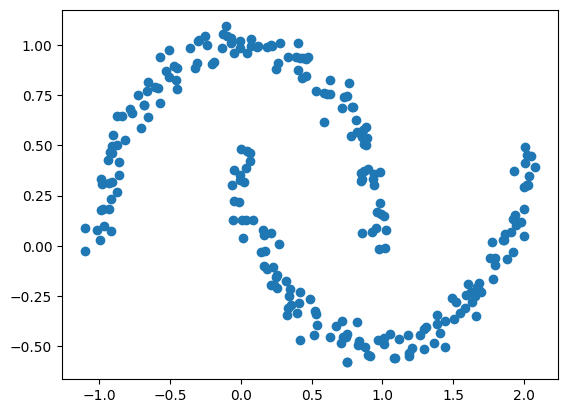

In [ ]:
dbcan.labels_
plt.scatter(x[:,0],x[:,1])


In [42]:
import pandas as pd
import numpy as np

# Creating a sample dataset with missing categorical values
data = {
    'Customer_ID': range(1, 16),
    'Shopping_Method': ['Online', 'Offline', 'Hybrid', 'Online', 'Offline',
                        np.nan, 'Online', 'Hybrid', np.nan, 'Offline',
                        'Online', 'Hybrid', 'Offline', np.nan, 'Hybrid']
}

df = pd.DataFrame(data)

# Display the dataset
print(df)


    Customer_ID Shopping_Method
0             1          Online
1             2         Offline
2             3          Hybrid
3             4          Online
4             5         Offline
5             6             NaN
6             7          Online
7             8          Hybrid
8             9             NaN
9            10         Offline
10           11          Online
11           12          Hybrid
12           13         Offline
13           14             NaN
14           15          Hybrid


In [ ]:
# # Find the mode(s)
# modes = df['Shopping_Method'].mode()
# print("Modes:", modes.tolist())  # Output: List of mode values


In [43]:
df['Shopping_Method'].fillna(df['Shopping_Method'].mode(), inplace=True)
print(df)


    Customer_ID Shopping_Method
0             1          Online
1             2         Offline
2             3          Hybrid
3             4          Online
4             5         Offline
5             6             NaN
6             7          Online
7             8          Hybrid
8             9             NaN
9            10         Offline
10           11          Online
11           12          Hybrid
12           13         Offline
13           14             NaN
14           15          Hybrid
